# Quickstart: Build and Compare a Few Proximity Graphs

This notebook is the smallest visual entry point for `proximitygraphs`. It builds a deterministic 3x3 grid, constructs several classical graph families on the same points, saves a comparison image, and displays a compact metrics table.

Artifacts are written to `examples/output/quickstart_notebook/`.

## Setup

The path setup lets this notebook run from the repository root or from inside the `examples/` folder. The notebook reuses the helper functions from `quickstart.py` so the script and notebook stay consistent.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "examples").exists():
            return path
    raise RuntimeError("Run this notebook from the repository or examples folder.")


REPO_ROOT = find_repo_root()
EXAMPLES_DIR = REPO_ROOT / "examples"
OUTPUT_DIR = EXAMPLES_DIR / "output" / "quickstart_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(EXAMPLES_DIR))

import quickstart

## Build the Graphs

All graphs below are built on the same 3x3 grid. That makes the visual and metric comparison direct: every graph has the same vertices, only the edge rule changes.

In [2]:
points, graphs = quickstart.build_graphs()

print(f"points: {points.n}")
for name, graph in graphs.items():
    print(f"{name}: {graph.m} edges, {graph.cc} component(s)")

points: 9
MST: 8 edges, 1 component(s)
Unit disk: 12 edges, 1 component(s)
Gabriel: 12 edges, 1 component(s)
Relative neighborhood: 12 edges, 1 component(s)
Delaunay: 16 edges, 1 component(s)


## Visual Comparison

The minimum spanning tree is the sparse backbone. The unit disk, Gabriel, and relative-neighborhood graphs coincide on this grid/radius choice. Delaunay is denser because it triangulates the point set.

examples\output\quickstart_notebook\graph_gallery.png


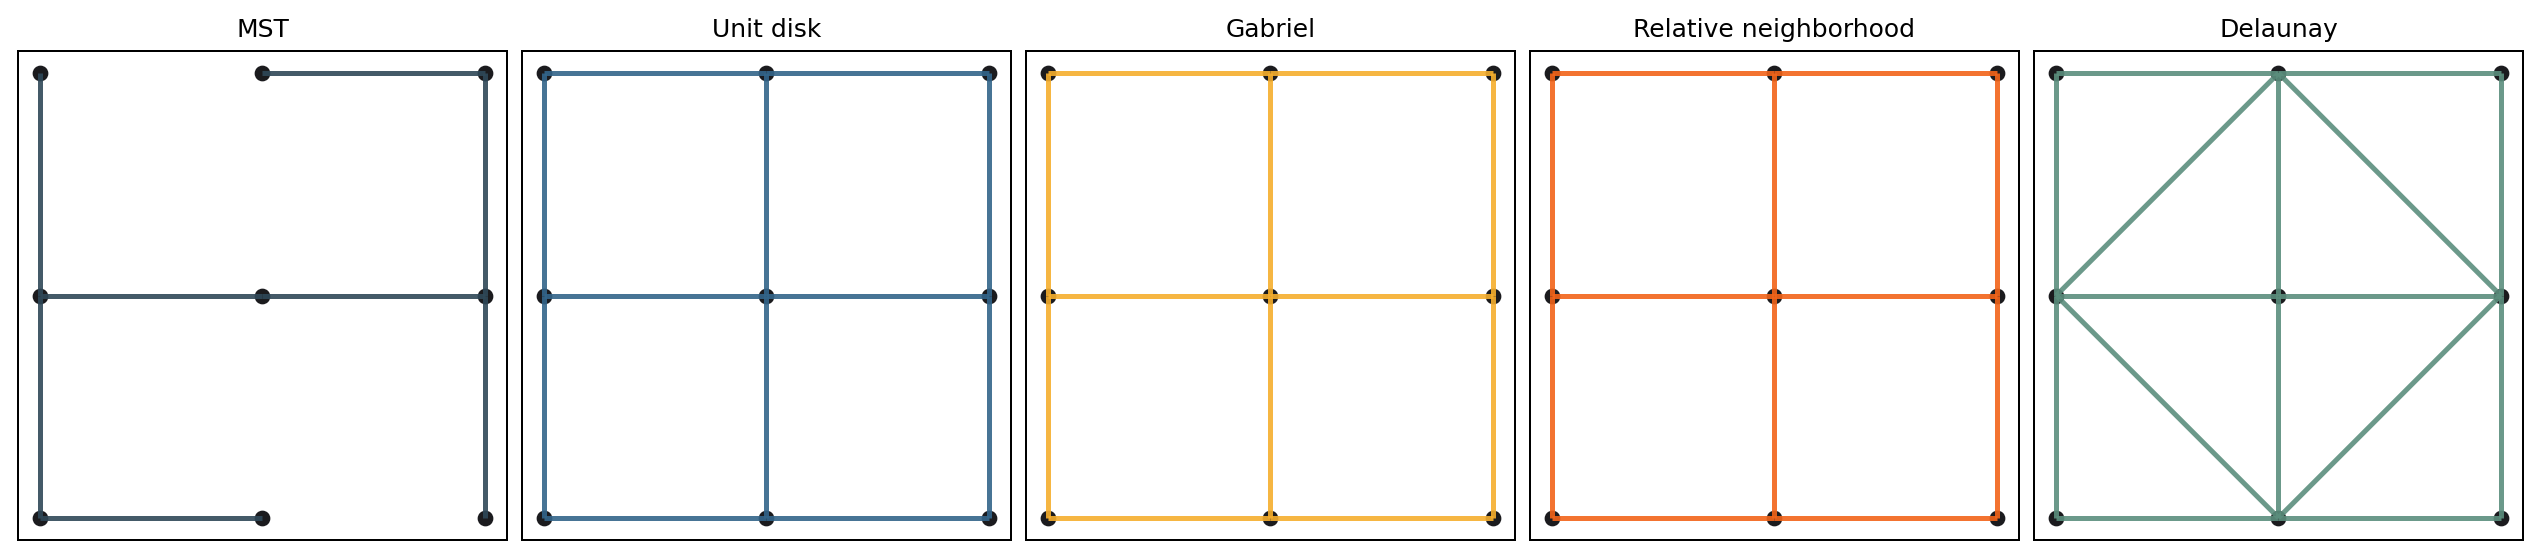

In [3]:
gallery_path = quickstart.save_graph_gallery(graphs, OUTPUT_DIR)
print(gallery_path.relative_to(REPO_ROOT))
display(Image(filename=str(gallery_path)))

## Metrics

The table keeps the comparison simple: edge count, connected components, density, and total edge length.

In [4]:
metrics = quickstart.graph_metrics(graphs)
csv_path, markdown_path = quickstart.write_metrics(metrics, OUTPUT_DIR)

print(csv_path.relative_to(REPO_ROOT))
print(markdown_path.relative_to(REPO_ROOT))
metrics

examples\output\quickstart_notebook\metrics.csv
examples\output\quickstart_notebook\metrics.md


,graph,vertices,edges,components,density,total_length
0,MST,9,8,1,0.2222,8.0000
1,Unit disk,9,12,1,0.3333,12.0000
2,Gabriel,9,12,1,0.3333,12.0000
3,Relative neighborhood,9,12,1,0.3333,12.0000
4,Delaunay,9,16,1,0.4444,17.6569


## Next Steps

After this quick example, try `all_graph_classes_gallery.ipynb` for a full visual comparison of every graph class, including the bio-inspired models.